In [ ]:
"""This project analyzes flight cancellations across the United States (USA) from January–June 2026).
    The objective is to identify patterns cancellation and determine whether cancellation rates differ 
    according to factors such as airline, origin airport, route, departure time, day of the week, and month.
    The data used in this project comes from the U.S. Department of Transportation (USDOT), Bureau of 
    Transportation Statistics (BTS)."""

In [15]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [5]:
files=glob.glob('T_ONTIME_REPORTING*.csv')
df = pd.concat([pd.read_csv(file) for file in files],  ignore_index=True)

In [6]:
df.shape

(3488373, 34)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3488373 entries, 0 to 3488372
Data columns (total 34 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   YEAR                   int64  
 1   MONTH                  int64  
 2   DAY_OF_MONTH           int64  
 3   DAY_OF_WEEK            int64  
 4   OP_UNIQUE_CARRIER      str    
 5   TAIL_NUM               str    
 6   OP_CARRIER_FL_NUM      int64  
 7   ORIGIN_AIRPORT_ID      int64  
 8   ORIGIN_AIRPORT_SEQ_ID  int64  
 9   ORIGIN_CITY_MARKET_ID  int64  
 10  ORIGIN                 str    
 11  DEST_AIRPORT_ID        int64  
 12  DEST_AIRPORT_SEQ_ID    int64  
 13  DEST_CITY_MARKET_ID    int64  
 14  DEST                   str    
 15  CRS_DEP_TIME           int64  
 16  DEP_DELAY              float64
 17  CRS_ARR_TIME           int64  
 18  CANCELLED              float64
 19  CANCELLATION_CODE      str    
 20  DIVERTED               float64
 21  CRS_ELAPSED_TIME       float64
 22  ACTUAL_ELAPSED_TIME    float6

In [8]:
df.isna().sum()

YEAR                           0
MONTH                          0
DAY_OF_MONTH                   0
DAY_OF_WEEK                    0
OP_UNIQUE_CARRIER              0
TAIL_NUM                   11167
OP_CARRIER_FL_NUM              0
ORIGIN_AIRPORT_ID              0
ORIGIN_AIRPORT_SEQ_ID          0
ORIGIN_CITY_MARKET_ID          0
ORIGIN                         0
DEST_AIRPORT_ID                0
DEST_AIRPORT_SEQ_ID            0
DEST_CITY_MARKET_ID            0
DEST                           0
CRS_DEP_TIME                   0
DEP_DELAY                  73847
CRS_ARR_TIME                   0
CANCELLED                      0
CANCELLATION_CODE        3412291
DIVERTED                  612102
CRS_ELAPSED_TIME               2
ACTUAL_ELAPSED_TIME        85752
DISTANCE                       0
CARRIER_DELAY            2735651
WEATHER_DELAY            2735651
NAS_DELAY                2735651
SECURITY_DELAY           2735651
LATE_AIRCRAFT_DELAY      2735651
FL_DATE                  2876271
DEP_DELAY_

In [9]:
# Explanatory Analysis
# Investigate where those 25,635 cancellations come from.

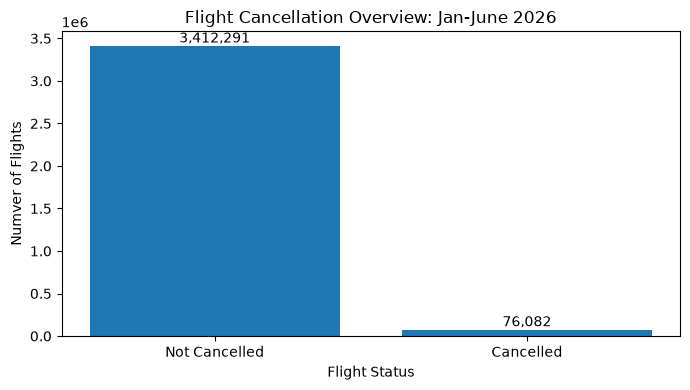

In [139]:
# Visualization -cancellation
# The overall distribution of cancelled vs non-cancelled flights.
cancellation_counts= df['CANCELLED'].value_counts().sort_index()
lables=['Not Cancelled','Cancelled']
plt.figure(figsize=(7,4))
plt.bar(lables,cancllation_counts.values)

plt.title('Flight Cancellation Overview: Jan-June 2026')
plt.xlabel('Flight Status')
plt.ylabel('Numver of Flights')

for i, value in enumerate(cancellation_counts.values):
    plt.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('images/cancellation_balance.png', dpi=300,bbox_inches='tight')

plt.show()

In [21]:
# Check Cancellation rate if varies considerably by month
month= df.groupby('MONTH')['CANCELLED'].agg(
    flights='count', cancellations='sum', cancellation_rate='mean').sort_values('cancellation_rate',ascending=False)
month
#Flight cancellation rates varied substantially across January–June 2026, ranging from 0.90% in April to 4.71% in January.

,flights,cancellations,cancellation_rate
MONTH,,,
1,544003,25635.0,0.047123
3,612102,17766.0,0.029025
2,515037,11605.0,0.022532
6,607577,10019.0,0.016490
5,611735,5655.0,0.009244
4,597919,5402.0,0.009035


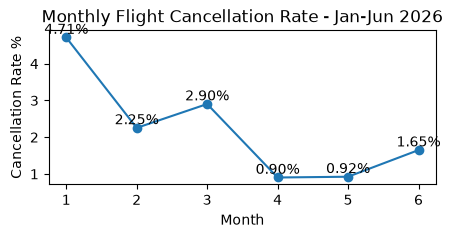

In [141]:
# Monthly Flight Cancellation Rate
month=month.sort_index()
plt.figure(figsize=(5,2))
plt.plot(month.index,month['cancellation_rate']*100, marker='o')
plt.title('Monthly Flight Cancellation Rate - Jan-Jun 2026')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate %')
for x, y in zip(month.index, month['cancellation_rate'] * 100):
    plt.text(
        x,
        y + 0.1,
        f'{y:.2f}%',
        ha='center'
    )
plt.savefig('images/montly_cancellation.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# How cancellation risk differs among airlines in the dataset.
carrier=df.groupby('OP_UNIQUE_CARRIER')['CANCELLED'].agg(
    flights='count', cancellations='sum',cancellation_rate='mean').query('flights>=5000').sort_values(
    'cancellation_rate', ascending=False)
carrier

,flights,cancellations,cancellation_rate
OP_UNIQUE_CARRIER,,,
NK,47202,3525.0,0.074679
OH,120424,6772.0,0.056235
YX,182909,8041.0,0.043962
AA,493947,14499.0,0.029353
B6,118580,3389.0,0.028580
MQ,158744,4240.0,0.026710
DL,509605,10647.0,0.020893
OO,424414,8569.0,0.020190
F9,106624,2127.0,0.019949


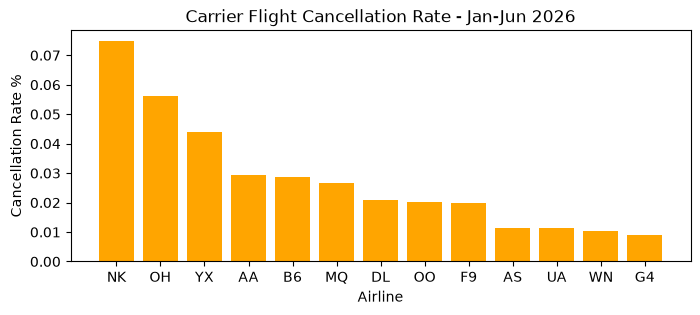

In [142]:
# Shows the difference in cancellation rates between carriers,
carrier = carrier.sort_values('cancellation_rate', ascending=False)
plt.figure(figsize=(8,3))
bar=plt.bar(carrier.index, carrier['cancellation_rate'], color='orange')
plt.title('Carrier Flight Cancellation Rate - Jan-Jun 2026')
plt.xlabel('Airline')
plt.ylabel('Cancellation Rate %')

plt.savefig('images/cancellation_carrier.png', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
# Does departure airports showed substantial differences in cancellation risk
origin=df.groupby('ORIGIN')['CANCELLED'].agg(
    flights='count',cancellations='sum', cancellation_rate='mean').query('flights >= 5000').sort_values(
    'cancellation_rate', ascending=False).head(20)
origin

,flights,cancellations,cancellation_rate
ORIGIN,,,
LGA,66761,3613.0,0.054118
HPN,5187,225.0,0.043378
DCA,70971,3056.0,0.043060
GSO,5056,206.0,0.040744
DFW,153176,5850.0,0.038191
PVD,7527,277.0,0.036801
MSN,6964,243.0,0.034894
RIC,9558,332.0,0.034735
MYR,5988,207.0,0.034569


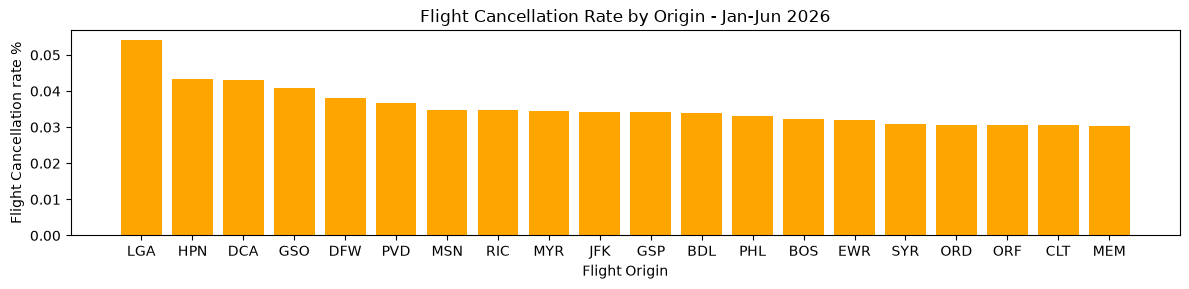

In [145]:
# Flight Origin- Cancellaion
origin=origin.sort_values('cancellation_rate', ascending=False)
plt.figure(figsize=(12,3))
plt.bar(origin.index, origin['cancellation_rate'], color='orange')

plt.title('Flight Cancellation Rate by Origin - Jan-Jun 2026')
plt.xlabel('Flight Origin')
plt.ylabel('Flight Cancellation rate %')
plt.tight_layout()


plt.savefig('images/Origin_cancellation.png', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
# Does the scheduled departure hour have a relationship with cancellation risk?
df['DEP_HOUR']=(df['CRS_DEP_TIME'] // 100).astype(int)
dep_hour = df.groupby('DEP_HOUR')['CANCELLED'].agg(
    flight='count',cancellation='sum',cancellation_rate='mean').sort_values('cancellation_rate', ascending=False)
dep_hour

,flight,cancellation,cancellation_rate
DEP_HOUR,,,
1,1869,68.0,0.036383
21,116992,3684.0,0.031489
4,96,3.0,0.031250
22,78853,2453.0,0.031109
3,291,9.0,0.030928
19,193540,5498.0,0.028408
20,156273,4107.0,0.026281
18,205556,5228.0,0.025433
17,221398,5588.0,0.025240


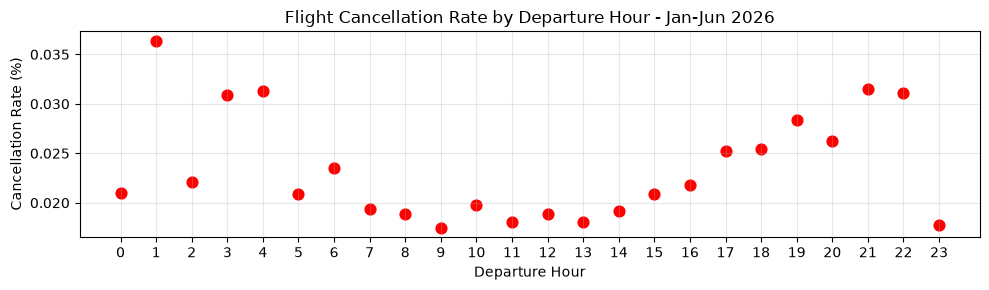

In [147]:
plt.figure(figsize=(10,3))
plt.scatter(dep_hour.index, dep_hour['cancellation_rate'], s=60,color='red')

plt.title('Flight Cancellation Rate by Departure Hour - Jan-Jun 2026')
plt.xlabel('Departure Hour')
plt.ylabel('Cancellation Rate (%)')


plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/cancellation_by_departure_hour.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Check departure airport and destination airport
route_status=df.groupby(['ORIGIN','DEST'])['CANCELLED'].agg(
    flights='count', cancellations='sum', cancellation_rate='mean')
route_status=route_status.query('flights>=5000').sort_values('cancellation_rate', ascending=False)
route_status

In [96]:
days=df.groupby('DAY_OF_WEEK')['CANCELLED'].agg(
    flights='count',cancellations='sum',cancellation_rate='mean').sort_values('cancellation_rate', ascending=False)
days

,flights,cancellations,cancellation_rate
DAY_OF_WEEK,,,
7,521077,20317.0,0.038990
1,524633,17959.0,0.034232
6,458358,10610.0,0.023148
2,471463,8635.0,0.018315
5,527828,8135.0,0.015412
3,461172,5150.0,0.011167
4,523842,5276.0,0.010072


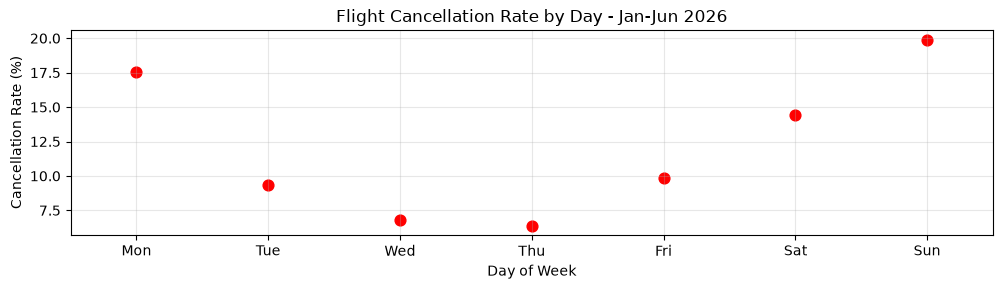

In [148]:
days = df.groupby('DAY_OF_WEEK').agg({'FL_DATE': 'count',  'CANCELLED': 'sum'})

days['cancellation_rate'] = days['CANCELLED'] / days['FL_DATE']
plt.figure(figsize=(10,3))
plt.scatter(days.index, days['cancellation_rate'] * 100, s=60, color='red')

plt.title('Flight Cancellation Rate by Day - Jan-Jun 2026')
plt.xlabel('Day of Week')
plt.ylabel('Cancellation Rate (%)')

plt.xticks([1, 2, 3, 4, 5, 6, 7], ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.xlim(0.5, 7.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/rate_by_date',dpi=300, bbox_inches='tight')
plt.show()